<a href="https://colab.research.google.com/github/sourabhverma1302/AI-ML-Journey/blob/main/Titanic_DataSet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

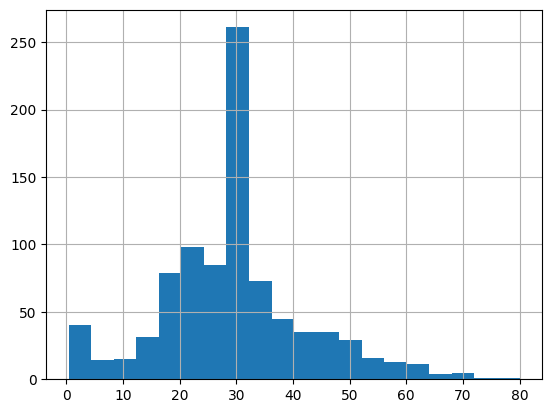

0.8100558659217877
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

0.7932960893854749
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       105
           1       0.78      0.70      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



In [62]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report
from sklearn.ensemble import RandomForestClassifier


data=pd.read_csv('./train.csv')
df=pd.DataFrame(data)

df["Age"]=df["Age"].fillna(df["Age"].mean()).round(1)
df=df.dropna(axis=1)


survived_passengers=df["Survived"].value_counts()
print(survived_passengers)

labels=["Survived","Dead"]
plt.bar(labels,survived_passengers,color=["Orange","Blue"])
plt.show()



#checking how many female survived with respect to male

x=df.groupby("Sex")["Survived"].mean().round(2)

sex_lables=["Female","Male"]

pd.crosstab(df["Sex"], df["Survived"], normalize="index")

plt.bar(sex_lables,(x)*100,color=["Violet","Blue"])
plt.show()
print(x)





print(df.head())
age_mean=df.groupby("Survived")["Age"].mean().round(0)
sex_age_mean=df.groupby("Sex")["Age"].mean().round(0)
pclass_survived=pd.crosstab(df["Survived"],df["Pclass"],normalize="index")
print(pclass_survived)
print(age_mean)

df["Age"].hist(bins=20)
plt.show()

df["Sex"]=df["Sex"].apply(lambda x: 1 if x == "male" else 0)

inputs=["Age","Sex","Pclass"]

X=df[inputs]
y=df['Survived']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=LogisticRegression()
model.fit(X_train,y_train) #training model

y_pred=model.predict(X_test)


my_accuracy_score=accuracy_score(y_test,y_pred)
my_classification_report=classification_report(y_test,y_pred)
print(my_accuracy_score)
print(my_classification_report)


other_model=RandomForestClassifier(n_estimators=100,random_state=42)
other_model.fit(X_train,y_train)

y_pred_other=other_model.predict(X_test)

my_accuracy_score_other=accuracy_score(y_test,y_pred_other)
my_classification_report_other=classification_report(y_test,y_pred_other)

print(my_accuracy_score_other)
print(my_classification_report_other)








# print(df.describe())